# 单代理架构

基于LangGraph的State状态定义模式，围绕LangGraph的State进入更高级的功能开发和探索阶段。

首先探讨的是LangGraph中的代理架构，即在LangGraph框架下都能够通过哪些代理模型来构建应用。

AI Agent的核心目标是实现更高程度的智能化，用户仅需输入一个需求，而无需关心处理过程的具体细节。

随着应用变得越来越复杂，基于大模型构建的系统需要具备更强的流程控制权，才能解决更复杂的问题。

在代理架构模式下，大模型可以通过多种方式获得流程控制权：最基础的是路径选择能力，即在多个潜在执行分支中做出决策；同时，每个分支路径上可集成多个工具，由大模型自主决定调用哪一个工具完成任务。在更复杂的场景中，大模型还能对生成的答案进行自我评估，若结果不满足需求，可自动启动额外工作流程，直到输出符合预期的答案。

从这个角度出发，LangGraph框架接入了：路由代理、工具代理、自主循环代理、多代理，这四类代理架构，以支持不同的场景需求。

# 路由代理Routing Agent

路由代理其实就类似于if-else语句，用于根据不同的条件选择不同的执行路径。这种方式允许大模型从一组预设的选项中选择合适的步骤来进行执行。

简单示例

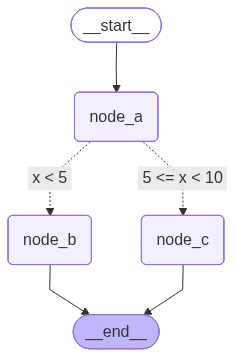

In [ ]:
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image
from typing import TypedDict  # <-- 必须加

# 定义正确的状态
class State(TypedDict):
    x: int

# 定义节点
def node_a(state):
    return {"x": state["x"] + 1}

def node_b(state):
    return {"x": state["x"] - 2}

def node_c(state):
    return {"x": state["x"] + 1}

# 定义路由函数，供条件边使用
def route(state):
    x = state["x"]
    if x < 5:
        return "x < 5"
    elif 5 <= x < 10:
        return "5 <= x < 10"

# 定义图（使用 TypedDict的 State 作为状态类型）
builder = StateGraph(State)

builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

builder.set_entry_point("node_a") # 设置入口节点

# 构建条件边
builder.add_conditional_edges(
    "node_a",
    route,
    {
        "x < 5": "node_b",
        "5 <= x < 10": "node_c",
    }
)

builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

graph = builder.compile()

# 画图
display(Image(graph.get_graph().draw_mermaid_png()))

LangGraph构建条件边并非难事(add_conditional_edges)，只需要在构建图时，添加一个条件边即可；同时要定义一个路由函数，该函数需要返回一个字符串，字符串表示条件边的条件。

Agent的开始节点(Start，即"node_a")接收信息，根据输入信息的不同，流程通过Router节点函数进行决策，讲不通的输入信息引导到不同的节点。

这里的核心是Router节点函数，它根据输入信息的结构和内容，动态地决定下一步应执行的节点。例如，对于具体的查询请求，Router决定需要访问数据库（Mysql节点），而对于简单的问候请求（如"你好"），Router决定直接返回响应（Response节点）。每个决策路径最终都指向一个结束节点（End）

**在构建Agent时，Router fuction的定义才是最关键且最重要的。需要在这个函数中，基于特定的一些格式或者标识来区分该执行哪一条分支的逻辑。而对于消息的传递，大模型往往是通过结构化输出，引导其在响应的过程中应遵循哪种模式来工作，就类似于工具调用过程。Router就很好的利用到了这个特性，通过结构化输出的特性来控制接下来的分支路径。**

关于结构化输出，在LangGraph中，实现结构化输出可以通过三种方式完成：
- 提示工程：指示大模型以特定格式做出输出
- 输出解析器：采用后处理的方式从大模型的响应中提取结构化数据
- 工具调用：利用一些内置工具调用功能来生成结构化输出

### 提示工程做结构化输出

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate # 提示模板

key = "sk-edoptvsonubjhdxwfdklbvhwscmnkmycthcvlomfvpmdevqr"
url = "https://api.siliconflow.cn/v1"

# 定义模型实例
llm = ChatOpenAI(model="Qwen/Qwen2.5-7B-Instruct", # 免费模型
                 api_key=key,base_url=url,
                 temperature=0)

# 定义提示模板
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the user query. Wrap the output in `json`", # 让模型输出结构化的 JSON 数据
        ),
        ("human", "{query}"),
    ]
)

chain = prompt | llm # 链式调用， LangChain 的 “管道符 |” 语法
"""
chain = prompt | llm相当于:
prompt_value = prompt.invoke({"query": "xxx"})
llm_output = llm.invoke(prompt_value)
 """
ans = chain.invoke({"query": "我叫红豆希饭，今年23岁，邮箱地址是hdxf#qq.com，电话是0000000"})
print(ans.content) # 显示结构化输出


```json
{
  "name": "红豆希饭",
  "age": "今年",
  "age岁": 23,
  "email": "hdxf@qq.com",
  "phone": "电话是"
}
``ote:电话是"后面没有提供具体的电话号码。0json


直接通过提示工程让大模型自行实现结构化输出，但这种方式在复杂的Agent构建流程中非常不稳定，因为大模型的输出格式是不固定的，所以引入一个进阶的优化方法：后处理步骤，即在大模型输出后通过输出解析器来格式化大模型的输出(提示工程+输出解析器)，将其转换为结构化输出，这种做法可以提高输出的准确性和一致性。

### 提示工程+输出解析器

In [9]:
from langchain_core.messages import AIMessage # 导入AIMessage类用来表示大模型的输出消息
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
import re
import json
from typing import List

key = "sk-edoptvsonubjhdxwfdklbvhwscmnkmycthcvlomfvpmdevqr"
url = "https://api.siliconflow.cn/v1"

# 定义模型实例
llm = ChatOpenAI(model="Qwen/Qwen2.5-7B-Instruct", # 免费模型
                 api_key=key,base_url=url,
                 temperature=0)

# 解析器函数-输出解析器
def extract_json(message: AIMessage) -> List[dict]:
    """从字符串中提取```json ... ```块,
    参数：text(str): 包含JSON块的文本字符串
    返回：List[dict]: 提取的JSON字符串列表
    """
    text = message.content
    # 定义正则表达式模式来匹配JSON块
    pattern = r"```json(.*?)```"

    # 在字符串中查找模式的所有非重叠匹配
    matches = re.findall(pattern, text, re.DOTALL)

    # 返回匹配的JSON字符串列表，去掉任何开头或结尾的空格
    try:
        return [json.loads(match.strip()) for match in matches]
    except Exception:
        raise ValueError(f"Failed to parse: {message}")
    

# 定义提示模板
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the user query. Wrap the output in `json`",
        ),
        ("human", "{query}"),
    ]
)

# 构建链式调用，先生成文本，再提取 JSON
chain = prompt | llm | extract_json # 链式调用

ans = chain.invoke({"query": "我叫红豆希饭，今年23岁，邮箱地址是hdxf#qq.com，电话是0000000"})
print(ans)

[{'name': '红豆希饭', 'age': 23, 'email': 'hdxf@qq.com', 'phone': '0000000'}]


结果显示，通过定制化的输出解析器，将模型的输出转换为结构化的JSON数据会更加符合预期；
接下来有一个在LangGraph中更常用的，且效果更好的;

即直接使用其内置的工具方法：.with_structured_output()

### 工具方法 -内置工具方法

.with_structured_output()通过接受一个定义了所需输出属性的名称、类型和描述的模式作为输入，进而生成一个类似模型的Runnable(可运行单元的统一接口)。  
&emsp;&emsp;不同于常规模型输出的字符串或消息，这个Runnable输出一个与输入模式相匹配的结构化对象(符合定义的模式)。  
可以通过几种方式指定这种架构，包括：TypedDict类、JSON Schema、Pydantic类。  
如果采用TypedDict类或JSON Schema，Runnable将输出一个字典；  
若使用Pydantic类，Runnable将输出一个Pydantic对象

1.使用Pydantic做结构化输出

In [ ]:
from typing import Optional
from pydantic import BaseModel, Field # 使用Pydantic做结构化输出
from langchain_openai import ChatOpenAI

key = "sk-edoptvsonubjhdxwfdklbvhwscmnkmycthcvlomfvpmdevqr"
url = "https://api.siliconflow.cn/v1"

# 定义模型实例
llm = ChatOpenAI(model="Qwen/Qwen2.5-7B-Instruct", # 免费模型
                 api_key=key,base_url=url,
                 temperature=0)

# 定义Pydantic模型
class UserInfo(BaseModel): 
    """提取用户信息, 如姓名, 年龄, 邮箱, 电话等."""
    name: str = Field(description="The name of the user")
    age: Optional[int] = Field(description="The age of the user")
    email: str = Field(description="The email address of the user")
    phone: Optional[str] = Field(description="The phone number of the user")

# 使用 with_structured_output() 方法将LLM包装成一个结构化输出的版本，指定输出类型为UserInfo
structured_llm = llm.with_structured_output(UserInfo)

# 从非结构化文本中提取用户信息
ans = structured_llm.invoke("提取用户信息：我叫红豆希饭，今年23岁，邮箱地址是hdxf#qq.com，电话是0000000")
print(ans)

# structured_llm.invoke() 不能直接传字典 {"query": "..."}
# 只接受：字符串 / 消息列表 / 提示词模板

name='红豆希饭' age=23 email='hdxf@qq.com' phone='0000000'


对于.with_structured_output()方法，如果希望模型返回一个Pydantic对象只需要传入所需的Pydantic类即可，即UserInfo类;  
- UserInfo类继承BaseModel类，而BaseModel类是Pydantic库中的一个基类，用于定义数据模型

.with_structured_output()返回的是一个UserInfo的Pydantic对象，每个字段中则填充了在原始非结构文本中提取出来的结构化数据；经过这样的格式化输出，可以直接用于Agent路由。
即：模型返回了结构化对象 → 直接用对象里的字段做判断 → 决定下一步走哪个节点


In [3]:
if ans.age>18:
    print("成年人")
else : 
    print("未成年人")

if isinstance(ans, UserInfo):
    print("这是一个 UserInfo 实例")
else:
    print("这不是一个 UserInfo 实例")
# isinstance() 函数用于检查一个对象是否是某个类的实例

成年人
这是一个 UserInfo 实例


2.使用TypedDict做结构化输出

也可以使用TypedDict类定义结构化输出的模式，这就要复习到graph02.ipynb中提及的Annotated，
- Annotated允许在指定类型的同时附加额外的信息（例如，方法、操作符等）。

In [ ]:
from typing import Optional
from typing_extensions import Annotated, TypedDict# 使用TypedDict做结构化输出
from langchain_openai import ChatOpenAI

key = "sk-edoptvsonubjhdxwfdklbvhwscmnkmycthcvlomfvpmdevqr"
url = "https://api.siliconflow.cn/v1"

# 定义模型实例
llm = ChatOpenAI(model="Qwen/Qwen2.5-7B-Instruct", # 免费模型
                 api_key=key,base_url=url,
                 temperature=0)

# 定义TypedDict模型
class UserInfo(TypedDict):
    """提取用户信息, 如姓名, 年龄, 邮箱, 电话等."""
    name: Annotated[str, ..., "The user's name"]
    age: Annotated[Optional[int], None, "The user's age"]
    email: Annotated[str, ..., "The user's email address"]
    phone: Annotated[Optional[str], None, "The user's phone number"]

# 使用 with_structured_output() 方法将LLM包装成一个结构化输出的版本，指定输出类型为UserInfo
structured_llm = llm.with_structured_output(UserInfo)

# 从非结构化文本中提取用户信息
ans = structured_llm.invoke("我叫红豆希饭，今年23岁，邮箱地址是hdxf#qq.com，电话是0000000")
print(ans)

# structured_llm.invoke() 不能直接传字典 {"query": "..."}
# 只接受：字符串 / 消息列表 / 提示词模板

{'age': 223, 'email': 'hdxf@qq.com', 'name': '红豆希饭'}


使用TypedDict创建的“对象”实际是一个字典，他没有Pydantic那样的方法和属性，因此功能相对简单。
TypedDict主要用于静态类型检查，而不是运行时类型检查。  
- TypedDict输出的结构化数据：{'age': 223, 'email': 'hdxf@qq.com', 'name': '红豆希饭'}  
- Pydantic输出的结构化数据：name='红豆希饭' age=23 email='hdxf@qq.com' phone='0000000'

3.使用JSON Schema做结构化输出

对于Json Schema格式算是最熟悉常用的，它不需要导入或类，可以直接通过字典的形式清楚地准确记录每个参数，但代价是代码会更加冗长。

In [ ]:

from langchain_openai import ChatOpenAI

key = "sk-edoptvsonubjhdxwfdklbvhwscmnkmycthcvlomfvpmdevqr"
url = "https://api.siliconflow.cn/v1"

# 定义模型实例
llm = ChatOpenAI(model="Qwen/Qwen2.5-7B-Instruct", # 免费模型
                 api_key=key,base_url=url,
                 temperature=0)

# 定义 JSON Schema
json_schema = {
    "title": "user_info",
    "description": "Extracted user information",
    "type": "object",
    "properties": {
        "name": {
            "type": "string",
            "description": "The user's name",
        },
        "age": {
            "type": "integer",
            "description": "The user's age",
            "default": None,
        },
        "email": {
            "type": "string",
            "description": "The user's email address",
        },
        "phone": {
            "type": "string",
            "description": "The user's phone number",
            "default": None,
        },
    },
    "required": ["name", "email"],
}

# 使用 with_structured_output() 方法将LLM包装成一个结构化输出的版本，指定输出类型为FinalResponse
structured_llm = llm.with_structured_output(json_schema)

# 从非结构化文本中提取用户信息
ans = structured_llm.invoke("提取用户信息：我叫红豆希饭，今年23岁，邮箱地址是hdxf#qq.com，电话是0000000")
print(ans)

# structured_llm.invoke() 不能直接传字典 {"query": "..."}
# 只接受：字符串 / 消息列表 / 提示词模板

{'age': 23, 'email': 'hdxf@qq.com', 'name': '红豆希饭', 'phone': '0000000'}


三种不同的结构化输出方法，更常用Pydantic来处理路由决策

### 结合结构化输出构建路由图

基于Pydantic做结构化输出，通过定义一个包含Union类型属性的父模型来灵活地从多条路径中选择适当的路由分支。(LangGraph+结构化输出 做路由决策)  
- Union=“或者”，意思就这个字段可以是A类型，也可以是B类型，二选一(或多选一)
Response = Union[DirectAnswer, DatabaseQuery] # 输出要么是直接回答，要么是数据库查询语句
但是小模型跑不动，所以可以考虑替代方案

根据输出决定是查询数据库还是直接回答问题，可以创建一个统一的模型来封装可能的输出类型。


In [4]:
from typing import Union, Optional, Literal # 使用Union和Optional来定义更灵活的类型
from pydantic import BaseModel, Field # 使用Pydantic做结构化输出
from langchain_openai import ChatOpenAI

key = "sk-edoptvsonubjhdxwfdklbvhwscmnkmycthcvlomfvpmdevqr"
url = "https://api.siliconflow.cn/v1"

# 定义模型实例
llm = ChatOpenAI(model="Qwen/Qwen2.5-7B-Instruct", # 免费模型
                 api_key=key,base_url=url,
                 temperature=0)

# 用户结构信息
class UserInfo(BaseModel):
    """提取用户信息, 如姓名, 年龄, 邮箱, 电话等."""
    name: str = Field(description="The name of the user")
    age: Optional[int] = Field(description="The age of the user")
    email: str = Field(description="The email address of the user")
    phone: Optional[str] = Field(description="The phone number of the user")

# 普通聊天回复
class ConversationalResponse(BaseModel):
    """以亲切自然的方式回应用户的提问，保持友善且乐于助人的态度"""
    response: str = Field(description="A conversational response to the user's query")

# 定义最终响应模型，可以是用户信息或一般响应
"""
小模型跑不动会超时，所以暂时注释掉这个模型定义，等大模型跑得动了再放开
class FinalResponse(BaseModel):
    final_output: Union[UserInfo, ConversationalResponse]
"""
class FinalResponse(BaseModel): # 替换方案
    # 让模型先判断类型
    response_type: Literal["user_info", "chat"]
    user_info: Optional[UserInfo] = None
    chat_response: Optional[ConversationalResponse] = None


# 使用 with_structured_output() 方法将LLM包装成一个结构化输出的版本，指定输出类型为FinalResponse
structured_llm = llm.with_structured_output(FinalResponse)

# 从非结构化文本中提取用户信息或进行一般对话响应
ans1 = structured_llm.invoke("你好")
print(ans1)
print("-----")
ans2 = structured_llm.invoke("我叫红豆希饭，今年23岁，邮箱地址是hdxf#qq.com，电话是0000000")
print(ans2)

# structured_llm.invoke() 不能直接传字典 {"query": "..."}
# 只接受：字符串 / 消息列表 / 提示词模板

response_type='chat' user_info=UserInfo(name='用户1nnn', age=0, email='', phone='') chat_response=ConversationalResponse(response='你好！很高兴为你服务。')
-----
response_type='chat' user_info=UserInfo(name=' ', age=22, email='hdxf@qq.com', phone=' ') chat_response=ConversationalResponse(response='你好，红豆希饭！！22 nâ€ nâ€ 今年222 222 2岁了。。 你的邮箱地址是hdxf@qq.com，， 电话是 **未提供**。 nâ')
